## Imports

In [62]:
import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

## Loading dataset

The keras library provides a convenient way to load the MNIST dataset, which is a collection of 70,000 grayscale images of handwritten digits (0-9) with a resolution of 28x28 pixels. The dataset is split into a training set of 60,000 images and a test set of 10,000 images.

In [63]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

We can take a look at the training images and their corresponding labels to understand the dataset better. Each image is represented as a 2D array of pixel values, and the labels indicate which digit (0-9) each image corresponds to. Like we know from machine learning, the x data is the input (the images) and the y data is the output (the labels).

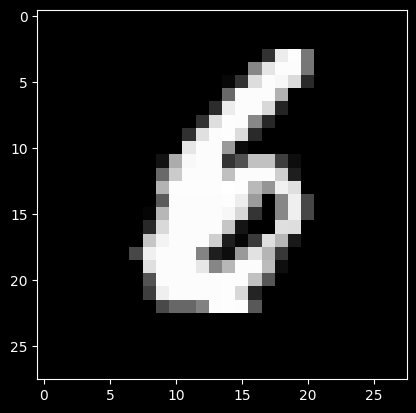

In [64]:
data_to_look = 129
plt.imshow(x_train[data_to_look], cmap='gray')

In [65]:
y_train[data_to_look]

np.uint8(6)

## Reshaping the data

We use reshape to flatten the 28x28 images into a 784-dimensional vector, which is the input format required for our simple neural network model. We also normalize the pixel values to be between 0 and 1 by dividing by 255.0, which helps the model to converge faster during training.

In [66]:
# Reshaping train and test data
x_train = x_train.reshape(60000, 784).astype("float32") / 255.0
x_test = x_test.reshape(10000, 784).astype("float32") / 255.0

## Building the model

keras.input() is used to define the input layer of the model, specifying the shape of the input data. In this case, we have 784 features (the pixel values of the flattened images). We then add two hidden layers with 32 and 16 neurons respectively, using the ReLU activation function to introduce non-linearity. Finally, we add an output layer with 10 neurons (one for each digit) and a softmax activation function to produce a probability distribution over the classes.

In [67]:
inputs = keras.Input(shape=(784,))

x = layers.Dense(32, activation="relu")(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="mnist_model")

In [68]:
model.summary()

Model: "mnist_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,818 (100.85 KB)

 Trainable params: 25,818 (100.85 KB)

 Non-trainable params: 0 (0.00 B)

## Training the model

Before training the model, we need to compile it by specifying the loss function, optimizer, and metrics. We use SparseCategoricalCrossentropy as the loss function since our labels are integers (not one-hot encoded), Adam as the optimizer for efficient training, and accuracy as the metric to evaluate the model's performance during training and validation.

In [69]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

We use model.fit() to train the model on the training data. We specify a batch size of 64, which means the model will update its weights after processing every 64 samples. We also set the number of epochs to 10, which means the model will go through the entire training dataset 10 times. The validation_split parameter is set to 0.2, which means that 20% of the training data will be used for validation during training, allowing us to monitor the model's performance on unseen data and prevent overfitting.

In [70]:
history = model.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8424 - loss: 0.5275 - val_accuracy: 0.9252 - val_loss: 0.2621
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9309 - loss: 0.2401 - val_accuracy: 0.9406 - val_loss: 0.2032
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9459 - loss: 0.1874 - val_accuracy: 0.9497 - val_loss: 0.1767
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9512 - loss: 0.1624 - val_accuracy: 0.9530 - val_loss: 0.1626
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9579 - loss: 0.1426 - val_accuracy: 0.9552 - val_loss: 0.1537
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9611 - loss: 0.1278 - val_accuracy: 0.9572 - val_loss: 0.1470
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9643 - loss: 0.1166 - val_accuracy: 0.9561 - val_loss: 0.1455
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9668 - loss: 0.1081 - val_accuracy: 0.

Understanding the training history is crucial for evaluating the model's performance and diagnosing potential issues such as overfitting or underfitting. The history object returned by model.fit() contains the loss and accuracy values for both the training and validation sets across all epochs. By plotting these values, we can visually assess how well the model is learning and whether it is generalizing effectively to unseen data. Generally we want to see the accuracy increasing and the loss decreasing over time.

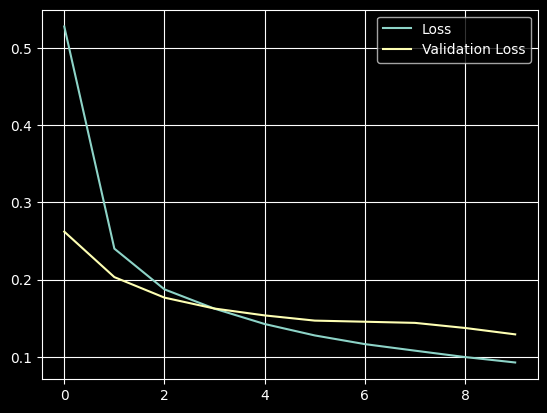

In [71]:
plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

Loss means how well the model is performing on the training data, while validation loss indicates how well the model is performing on unseen data. A decreasing loss and validation loss over epochs typically indicate that the model is learning effectively. However, if the validation loss starts to increase while the training loss continues to decrease, it may suggest that the model is overfitting to the training data and not generalizing well to new data.

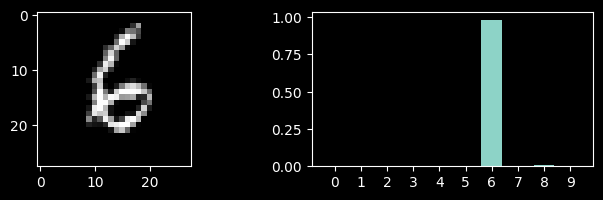

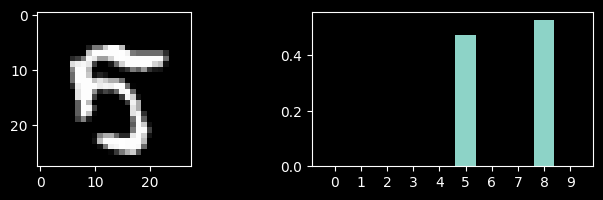

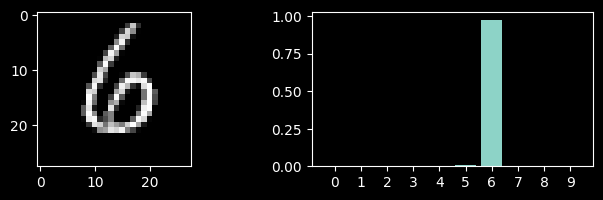

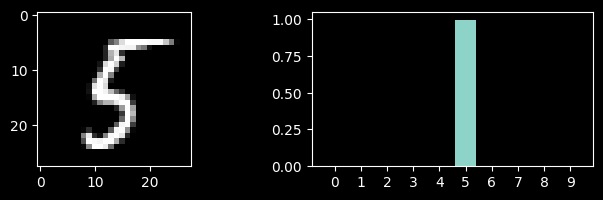

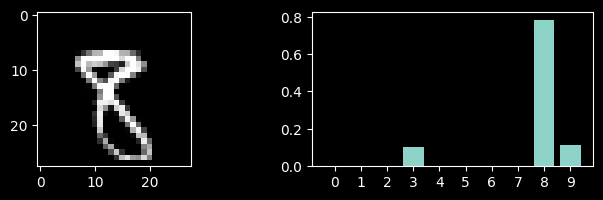

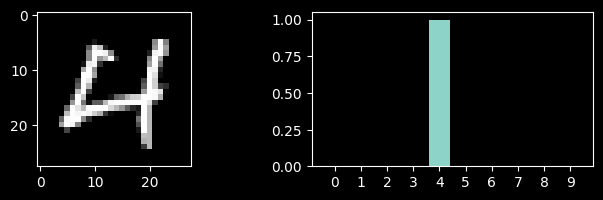

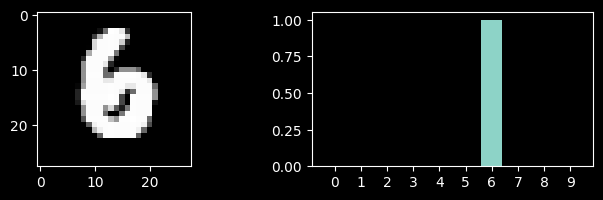

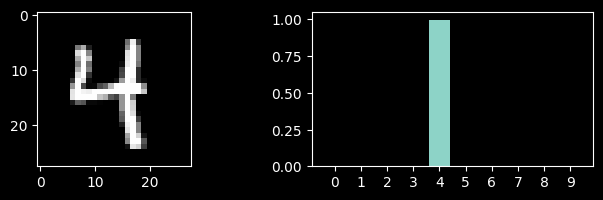

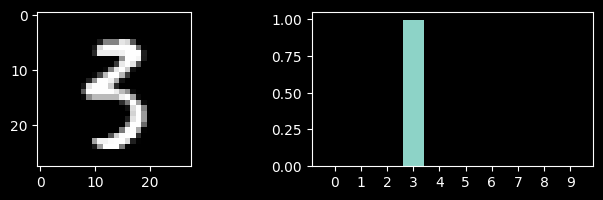

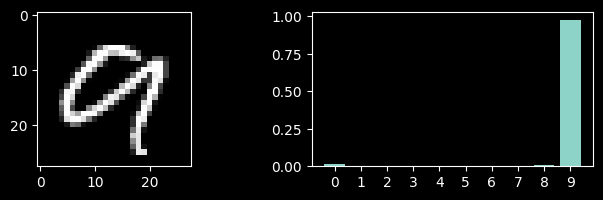

In [72]:
x = x_test
y = model(x)
start = 2000

for k in range(10):
    plt.figure(figsize=(8, 2))
    plt.subplot(1,2,1)
    plt.imshow(x[start+k].reshape((28, 28)), cmap='gray')
    ind = np.arange(0, 10)
    plt.subplot(1,2,2)
    plt.bar(ind, y[start+k].numpy().flatten())
    plt.xticks(range(10))

## Evaluating the model

After training the model, we can evaluate its performance on the test set using model.evaluate(). This function computes the loss and accuracy of the model on the test data, which provides an unbiased estimate of how well the model generalizes to new, unseen data. The test loss and test accuracy are important metrics to assess the effectiveness of the model after training.

In [73]:
test_score = model.evaluate(x_test, y_test, verbose=1)
print("Test loss:", test_score[0])
print("Test accuracy:", test_score[1])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9601 - loss: 0.1394
Test loss: 0.13941189646720886
Test accuracy: 0.960099995136261


Accuracy of around 0.95 indicates that the model is performing well on the test set, correctly classifying approximately 95% of the images. Test loss of around 0.15 suggests that the model's predictions are reasonably close to the true labels, with lower values indicating better performance. Overall, these results suggest that the simple neural network model is effective at recognizing handwritten digits in the MNIST dataset.